In [2]:
import warnings
warnings.filterwarnings("ignore")

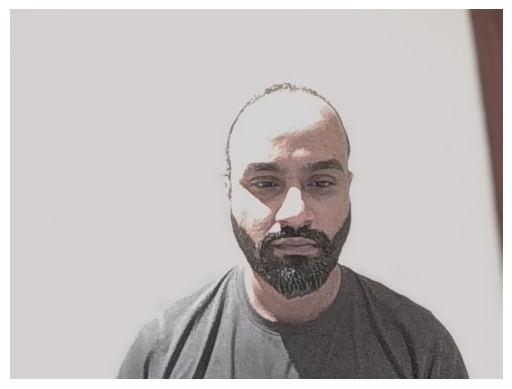

In [3]:
import cv2
import matplotlib.pyplot as plt

cap = cv2.VideoCapture(2)
ret, frame = cap.read()
cap.release()

if ret:
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.imshow(frame_rgb)
    plt.axis('off')
    plt.show()
else:
    print('Camera not available')


In [4]:
import cv2

print("🕵️ Testing camera indices...")

for i in range(3):  # Try indices 0, 1, 2
    print(f"\nTrying camera index {i}...")
    cap = cv2.VideoCapture(i)
    ret, frame = cap.read()
    if ret:
        print(f"✅ Camera index {i} is available!")
        cv2.imshow(f"Camera {i}", frame)
        print("   --> Showing camera preview for 3 seconds.")
        cv2.waitKey(3000)  # Show for 3 seconds
        cv2.destroyAllWindows()
    else:
        print(f"❌ Camera index {i} NOT available!")
    cap.release()

print("\nDone. Pick the index where your desired camera showed the live image.")
print("Set that index (0, 1, or 2) in your attendance script as video_index.")


🕵️ Testing camera indices...

Trying camera index 0...
✅ Camera index 0 is available!
   --> Showing camera preview for 3 seconds.

Trying camera index 1...
✅ Camera index 1 is available!
   --> Showing camera preview for 3 seconds.

Trying camera index 2...
✅ Camera index 2 is available!
   --> Showing camera preview for 3 seconds.

Done. Pick the index where your desired camera showed the live image.
Set that index (0, 1, or 2) in your attendance script as video_index.


In [5]:
import cv2
import numpy as np
import tensorflow as tf
import pickle
import pandas as pd
from datetime import datetime

# =========================
# STEP 1: Load Model and Labels
# =========================
print("🔄 Loading model...")
model = tf.keras.models.load_model("face_recognition_model.h5")
with open("label_mappings.pkl", "rb") as f:
    label_mappings = pickle.load(f)

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

# =========================
# STEP 2: Recognition Function
# =========================
def recognize_student(face_img):
    # Preprocess the detected face for prediction
    face_img = cv2.resize(face_img, (128, 128))
    face_img = cv2.cvtColor(face_img, cv2.COLOR_BGR2RGB)
    face_img = face_img.astype("float32") / 255.0
    face_img = np.expand_dims(face_img, axis=0)
    preds = model.predict(face_img, verbose=0)[0]
    predicted_index = int(np.argmax(preds))
    confidence = float(np.max(preds))
    roll_number = label_mappings['index_to_label'][predicted_index]
    return roll_number, confidence

# =========================
# STEP 3: Open Webcam and Detect Faces
# =========================
attendance_records = []
video_index = 2  # usually 0, try 1 or 2 if you have multiple webcams

cap = cv2.VideoCapture(video_index)
if not cap.isOpened():
    print("❌ ERROR: Could not open webcam. Try changing video_index to 1 or 2.")
    exit()

print("📷 Webcam active! Press 'q' to quit.")

while True:
    ret, frame = cap.read()
    if not ret:
        print("❌ ERROR: Failed to capture frame. Exiting.")
        break
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    for (x, y, w, h) in faces:
        cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)
        face = frame[y:y+h, x:x+w]
        if face.shape[0] > 0 and face.shape[1] > 0:
            roll_number, confidence = recognize_student(face)
            display_text = f"{roll_number} ({confidence:.2f})"
            color = (0, 255, 0) if confidence > 0.80 else (0, 0, 255)
            cv2.putText(frame, display_text, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)
            
            # Only record confident predictions (confidence > 0.80)
            if confidence > 0.80:
                attendance_records.append({
                    "roll_number": roll_number,
                    "confidence": confidence,
                    "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
                })

    cv2.imshow("Student Attendance System", frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        print("🛑 Quitting: Attendance session ended.")
        break

cap.release()
cv2.destroyAllWindows()

# =========================
# STEP 4: Save Attendance CSV
# =========================
if attendance_records:
    df = pd.DataFrame(attendance_records)
    df.drop_duplicates(subset=["roll_number"], keep="last", inplace=True)
    df.to_csv("student_attendance.csv", index=False)
    print("✅ Attendance saved to student_attendance.csv")
else:
    print("⚠️ No attendance records captured.")



🔄 Loading model...


📷 Webcam active! Press 'q' to quit.


KeyboardInterrupt: 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, normaltest, ttest_1samp

# Load the attendance CSV
df = pd.read_csv("student_attendance.csv")

# ========== 1. Descriptive Statistics ==========
print("\n=== DESCRIPTIVE STATISTICS ===\n")
print(f"Total records           : {len(df)}")
print(f"Unique students         : {df['roll_number'].nunique()}")
print(f"Confidence Mean         : {df['confidence'].mean():.3f}")
print(f"Confidence Std          : {df['confidence'].std():.3f}")
print(f"Confidence Median       : {df['confidence'].median():.3f}")
print(f"Min Confidence          : {df['confidence'].min():.3f}")
print(f"Max Confidence          : {df['confidence'].max():.3f}")

# ========== 2. Confidence Distribution Plot ==========
plt.figure(figsize=(8,6))
sns.histplot(df['confidence'], bins=30, kde=True)
plt.title("Distribution of Confidence Scores")
plt.xlabel("Confidence Score")
plt.ylabel("Density")
plt.show()

# ========== 3. Box Plot and Outlier Detection ==========
plt.figure(figsize=(6,5))
sns.boxplot(x=df['confidence'])
plt.title("Box Plot of Confidence Scores")
plt.xlabel("Confidence Score")
plt.show()

# ========== 4. Normality Tests ==========
print("\n=== NORMALITY TESTS ===\n")
stat, p = shapiro(df['confidence'])
print(f"Shapiro-Wilk Test: statistic={stat:.4f}, p-value={p:.4f}")
stat2, p2 = normaltest(df['confidence'])
print(f"D'Agostino's K² Test: statistic={stat2:.4f}, p-value={p2:.4f}")
if p < 0.05 or p2 < 0.05:
    print("Interpretation: Distribution is NOT normal")
else:
    print("Interpretation: Distribution looks normal")

# ========== 5. Confidence Interval ==========
mean = df['confidence'].mean()
std = df['confidence'].std()
n = len(df)
se = std / np.sqrt(n)
ci_l = mean - 1.96*se
ci_r = mean + 1.96*se
print(f"\n95% Confidence interval for mean: [{ci_l:.3f}, {ci_r:.3f}]")

# ========== 6. T-test vs Threshold (0.8) ==========
t_stat, t_p = ttest_1samp(df['confidence'], 0.8)
print(f"T-test vs threshold 0.8: t-stat={t_stat:.4f}, p-value={t_p:.4f}")
if t_p < 0.05:
    print("Interpretation: Mean confidence is significantly different from 0.8.")
else:
    print("Interpretation: Mean confidence is not significantly different from 0.8.")



In [9]:
import cv2
import numpy as np
import tensorflow as tf
import pickle
import pandas as pd

# STEP 1: Load model and labels
model = tf.keras.models.load_model("face_recognition_model.h5")
with open("label_mappings.pkl", "rb") as f:
    label_mappings = pickle.load(f)
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

# STEP 2: List your image files
image_paths = [
    'image11.jpg',  # replace with your actual filenames
    'image2.jpeg',
    'image3.jpeg'

]

results = []

for image_path in image_paths:
    img = cv2.imread(image_path)
    if img is None:
        print(f"❌ ERROR: Could not open {image_path}")
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)
    print(f"\n{len(faces)} face(s) detected in {image_path}")

    for (x, y, w, h) in faces:
        face = img[y:y+h, x:x+w]
        face_resized = cv2.resize(face, (128,128))
        face_rgb = cv2.cvtColor(face_resized, cv2.COLOR_BGR2RGB)
        face_rgb = face_rgb.astype("float32") / 255.0
        face_input = np.expand_dims(face_rgb, axis=0)
        preds = model.predict(face_input, verbose=0)[0]
        idx = int(np.argmax(preds))
        confidence = float(np.max(preds))
        roll_number = label_mappings['index_to_label'][idx]
        print(f"Detected: {roll_number} (confidence: {confidence:.3f})")
        cv2.rectangle(img, (x, y), (x+w, y+h), (0,255,0), 2)
        cv2.putText(img, f"{roll_number} ({confidence:.2f})", (x, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,0), 2)
        # Save results for CSV
        results.append({
            "image": image_path,
            "roll_number": roll_number,
            "confidence": confidence
        })

    # Display annotated image
    cv2.imshow(f"{image_path} - Detection", img)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

# STEP 3: Optional—save results to CSV
if results:
    df = pd.DataFrame(results)
    df.to_csv("image_detection_results.csv", index=False)
    print("\n✅ Results saved to image_detection_results.csv")



20 face(s) detected in image11.jpg
Detected: 23BCA10356 (confidence: 0.776)
Detected: 23mca20565 (confidence: 0.707)
Detected: GU81811 (confidence: 0.821)
Detected: GUSCSE202534452 (confidence: 0.844)
Detected: GU81811 (confidence: 0.800)
Detected: 23MCA20215 (confidence: 0.999)
Detected: GUSCSE202534452 (confidence: 0.979)
Detected: GUSCSE202534452 (confidence: 0.889)
Detected: GUSCSE202534452 (confidence: 0.966)
Detected: GUSCSE202534452 (confidence: 0.889)
Detected: 23MCA20388 (confidence: 0.530)
Detected: GUSCSE202534452 (confidence: 0.826)
Detected: GUGU202433170 (confidence: 0.488)
Detected: GUSCSE202534452 (confidence: 0.919)
Detected: GUGU202433170 (confidence: 0.273)
Detected: GUSCSE202534452 (confidence: 0.930)
Detected: GUSCSE202534452 (confidence: 0.944)
Detected: GUSCSE202534452 (confidence: 0.297)
Detected: GUSCSE202534452 (confidence: 0.690)
Detected: GU81811 (confidence: 0.472)

4 face(s) detected in image2.jpeg
Detected: 23MCA20302 (confidence: 0.232)
Detected: 23BCA1

===== GLOBAL STATISTICS =====
Total predictions: 30
Unique students detected: 14
Mean confidence: 0.720
Median confidence: 0.810
Std confidence: 0.241
Min / Max confidence: 0.232 — 0.999

===== IMAGE-LEVEL STATISTICS =====
             count      mean       std       min       max
image                                                     
image11.jpg     20  0.751945  0.224061  0.272621  0.998549
image2.jpeg      4  0.485041  0.200383  0.231831  0.685188
image3.jpeg      6  0.771507  0.265132  0.339888  0.945658

===== NORMALITY TESTS =====
Shapiro-Wilk: statistic=0.883, p=0.003
D’Agostino K²: statistic=4.362, p=0.113
95% CI for mean confidence: [0.634, 0.806]


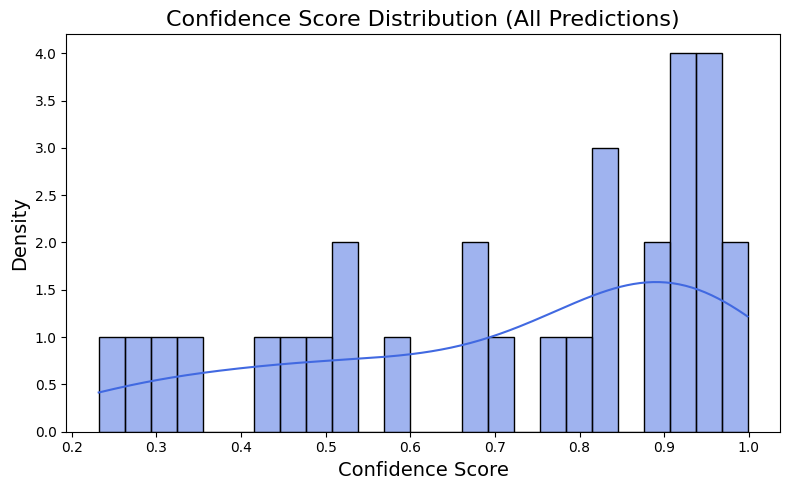

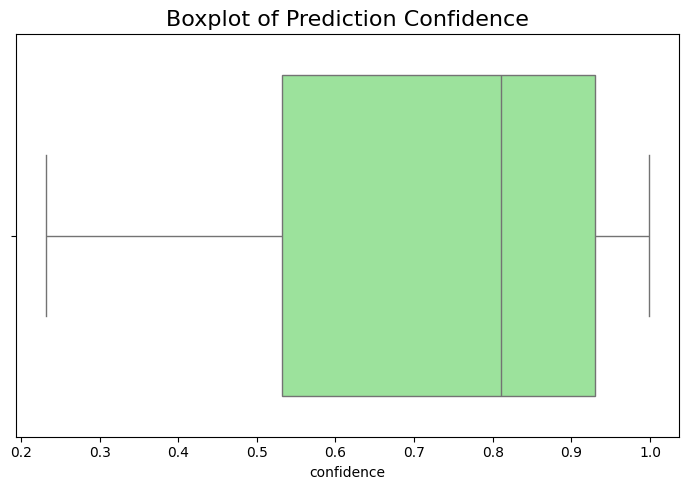

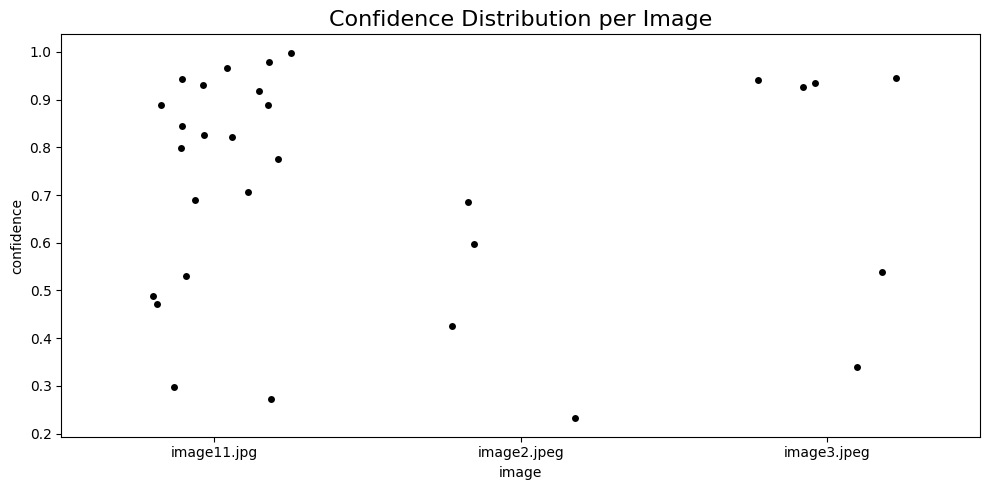

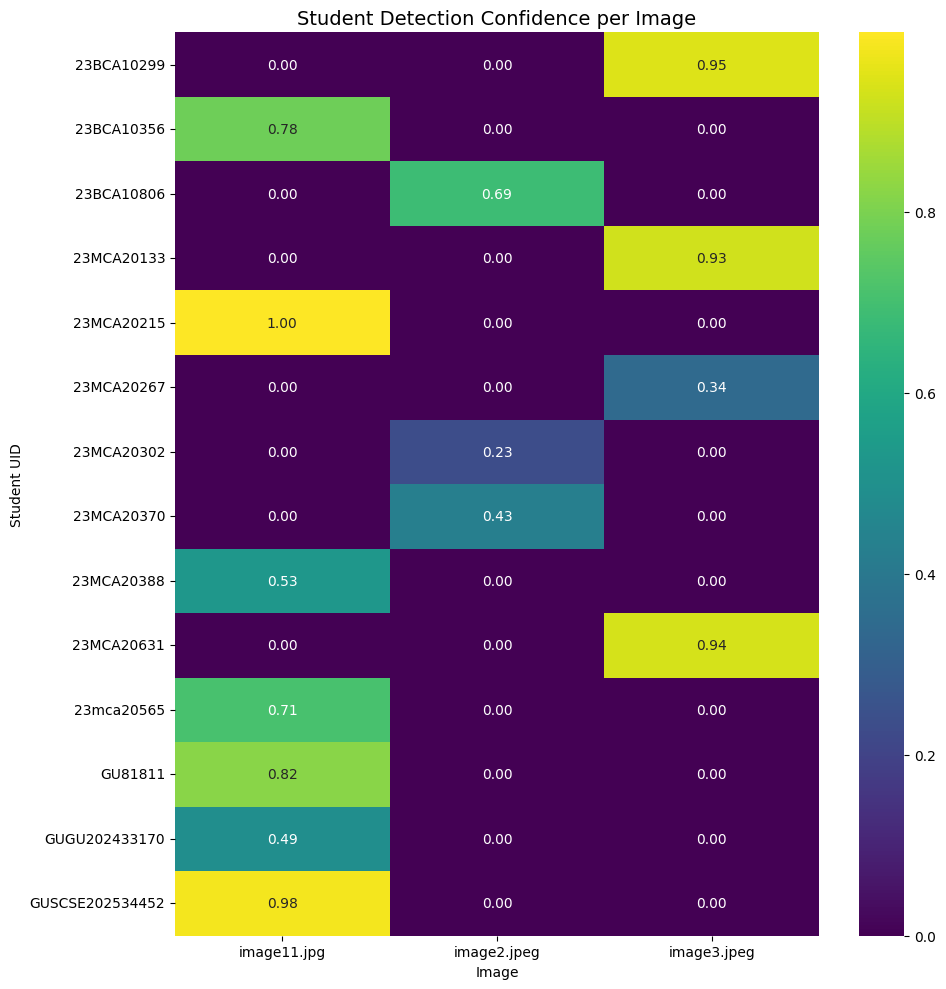

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import shapiro, normaltest, ttest_1samp

# ---- Load results ----
df = pd.read_csv('image_detection_results.csv')

# ---- Descriptive Statistics ----
print("===== GLOBAL STATISTICS =====")
print(f"Total predictions: {len(df)}")
print(f"Unique students detected: {df['roll_number'].nunique()}")
print(f"Mean confidence: {df['confidence'].mean():.3f}")
print(f"Median confidence: {df['confidence'].median():.3f}")
print(f"Std confidence: {df['confidence'].std():.3f}")
print(f"Min / Max confidence: {df['confidence'].min():.3f} — {df['confidence'].max():.3f}")

# ---- Image-level stats ----
print("\n===== IMAGE-LEVEL STATISTICS =====")
per_image = df.groupby('image')['confidence'].agg(['count','mean','std','min','max'])
print(per_image)

# ---- Normality tests ----
print("\n===== NORMALITY TESTS =====")
stat, p = shapiro(df['confidence'])
stat2, p2 = normaltest(df['confidence'])
print(f"Shapiro-Wilk: statistic={stat:.3f}, p={p:.3f}")
print(f"D’Agostino K²: statistic={stat2:.3f}, p={p2:.3f}")

# ---- Confidence interval ----
mean = df['confidence'].mean()
std = df['confidence'].std()
n = len(df)
se = std / np.sqrt(n)
ci_l = mean - 1.96 * se
ci_r = mean + 1.96 * se
print(f"95% CI for mean confidence: [{ci_l:.3f}, {ci_r:.3f}]")

# ---- Distribution plot ----
plt.figure(figsize=(8,5))
sns.histplot(df['confidence'], bins=25, kde=True, color='royalblue')
plt.title("Confidence Score Distribution (All Predictions)", fontsize=16)
plt.xlabel("Confidence Score", fontsize=14)
plt.ylabel("Density", fontsize=14)
plt.tight_layout()
plt.show()

# ---- Box plot ----
plt.figure(figsize=(7,5))
sns.boxplot(x='confidence', data=df, color='lightgreen')
plt.title("Boxplot of Prediction Confidence", fontsize=16)
plt.tight_layout()
plt.show()

# ---- Stripplot per image ----
plt.figure(figsize=(10,5))
sns.stripplot(x='image', y='confidence', data=df, color='black', jitter=0.25)
plt.title("Confidence Distribution per Image", fontsize=16)
plt.tight_layout()
plt.show()

# ---- Heatmap (if >1 prediction per image and >1 student) ----
pivot = df.pivot_table(index='roll_number', columns='image', values='confidence', aggfunc='max', fill_value=0)
plt.figure(figsize=(10,10))
sns.heatmap(pivot, cmap='viridis', annot=True, fmt='.2f')
plt.title("Student Detection Confidence per Image", fontsize=14)
plt.ylabel("Student UID")
plt.xlabel("Image")
plt.tight_layout()
plt.show()


In [14]:
import os
import cv2
import numpy as np
import tensorflow as tf
import pickle
import pandas as pd

# Load your model and label mapping
model = tf.keras.models.load_model("face_recognition_model.h5")
with open("label_mappings.pkl", "rb") as f:
    label_mappings = pickle.load(f)
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

# Set the folder containing images
image_folder = "./images"  # CHANGE this to your actual folder path
image_files = [f for f in os.listdir(image_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

results = []

for image_file in image_files:
    image_path = os.path.join(image_folder, image_file)
    img = cv2.imread(image_path)
    if img is None:
        print(f"❌ ERROR: Could not open {image_file}")
        continue
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)
    for (x, y, w, h) in faces:
        face = img[y:y+h, x:x+w]
        face_resized = cv2.resize(face, (128, 128))
        face_rgb = cv2.cvtColor(face_resized, cv2.COLOR_BGR2RGB)
        face_rgb = face_rgb.astype("float32") / 255.0
        face_input = np.expand_dims(face_rgb, axis=0)
        preds = model.predict(face_input, verbose=0)[0]
        idx = int(np.argmax(preds))
        confidence = float(np.max(preds))
        roll_number = label_mappings['index_to_label'][idx]
        results.append({
            "image_file": image_file,
            "predicted_UID": roll_number,
            "confidence": confidence,
            "x": x,
            "y": y,
            "w": w,
            "h": h
        })

# Save results to CSV
df = pd.DataFrame(results)
df.to_csv("face_predictions.csv", index=False)
print("✅ CSV file generated: face_predictions.csv")


✅ CSV file generated: face_predictions.csv


count    49.000000
mean      0.742509
std       0.231016
min       0.231831
25%       0.538172
50%       0.820824
75%       0.935798
max       0.999393
Name: confidence, dtype: float64

Predictions per student:
                 count      mean       std       min       25%       50%  \
predicted_UID                                                              
23BCA10299         3.0  0.808644  0.234242  0.538172  0.740137  0.942102   
23BCA10356         2.0  0.645830  0.184475  0.515387  0.580608  0.645830   
23BCA10806         2.0  0.641504  0.061779  0.597820  0.619662  0.641504   
23MCA20133         1.0  0.927427       NaN  0.927427  0.927427  0.927427   
23MCA20156         2.0  0.814492  0.039041  0.786886  0.800689  0.814492   
23MCA20215         2.0  0.998971  0.000597  0.998549  0.998760  0.998971   
23MCA20267         1.0  0.339888       NaN  0.339888  0.339888  0.339888   
23MCA20302         1.0  0.231831       NaN  0.231831  0.231831  0.231831   
23MCA20370         1.0  0.425

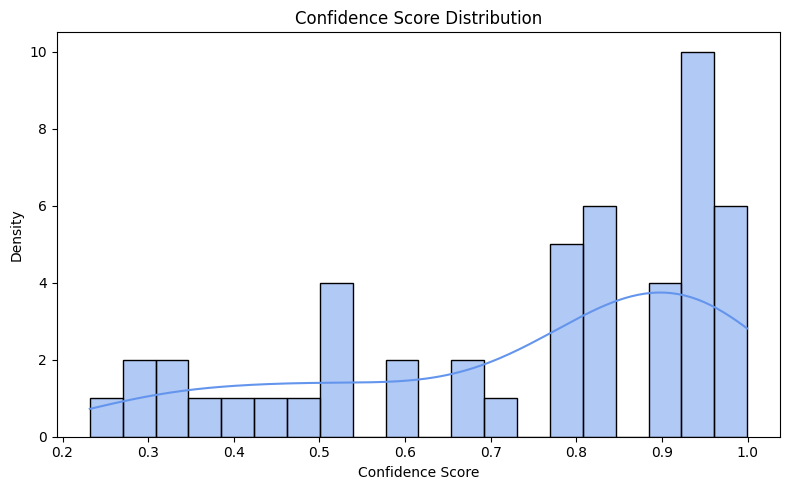

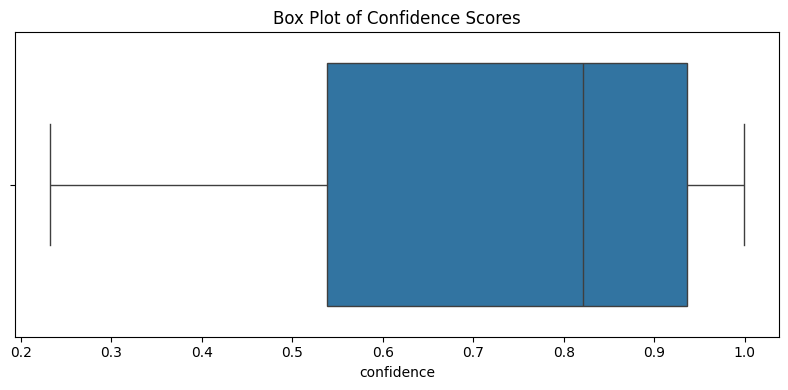

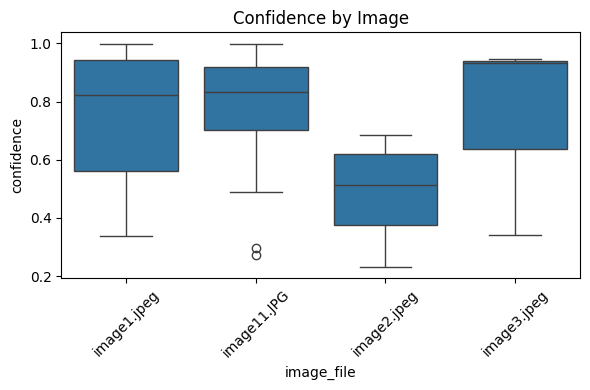

Shapiro-Wilk: statistic=0.869, p-value=0.000
Confidence distribution is NOT normal.
95% CI for mean confidence: [0.678, 0.807]
T-test vs 0.8: t-stat=-1.742, p-value=0.088
Mean confidence is not significantly different from 0.8.


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, ttest_1samp

df = pd.read_csv('face_predictions.csv')

# 1. Descriptive statistics
print(df['confidence'].describe())
print("\nPredictions per student:")
print(df.groupby('predicted_UID')['confidence'].describe())

# 2. Confidence Score Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['confidence'], bins=20, kde=True, color='cornflowerblue')
plt.title("Confidence Score Distribution")
plt.xlabel("Confidence Score")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

# 3. Boxplot
plt.figure(figsize=(8,4))
sns.boxplot(x='confidence', data=df)
plt.title("Box Plot of Confidence Scores")
plt.tight_layout()
plt.show()

# 4. Per-image average confidence
plt.figure(figsize=(6,4))
sns.boxplot(x='image_file', y='confidence', data=df)
plt.title("Confidence by Image")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 5. Normality test
sw_stat, sw_p = shapiro(df['confidence'])
print(f"Shapiro-Wilk: statistic={sw_stat:.3f}, p-value={sw_p:.3f}")
if sw_p < 0.05:
    print("Confidence distribution is NOT normal.")
else:
    print("Confidence distribution looks normal.")

# 6. Confidence interval for mean
mean = df['confidence'].mean()
std = df['confidence'].std()
n = len(df)
se = std / np.sqrt(n)
ci_l = mean - 1.96 * se
ci_r = mean + 1.96 * se
print(f"95% CI for mean confidence: [{ci_l:.3f}, {ci_r:.3f}]")

# 7. T-test vs threshold (e.g., 0.8)
t_stat, t_p = ttest_1samp(df['confidence'], 0.8)
print(f"T-test vs 0.8: t-stat={t_stat:.3f}, p-value={t_p:.3f}")
if t_p < 0.05:
    print("Mean confidence is significantly different from 0.8.")
else:
    print("Mean confidence is not significantly different from 0.8.")


count    49.000000
mean      0.742509
std       0.231016
min       0.231831
25%       0.538172
50%       0.820824
75%       0.935798
max       0.999393
Name: confidence, dtype: float64


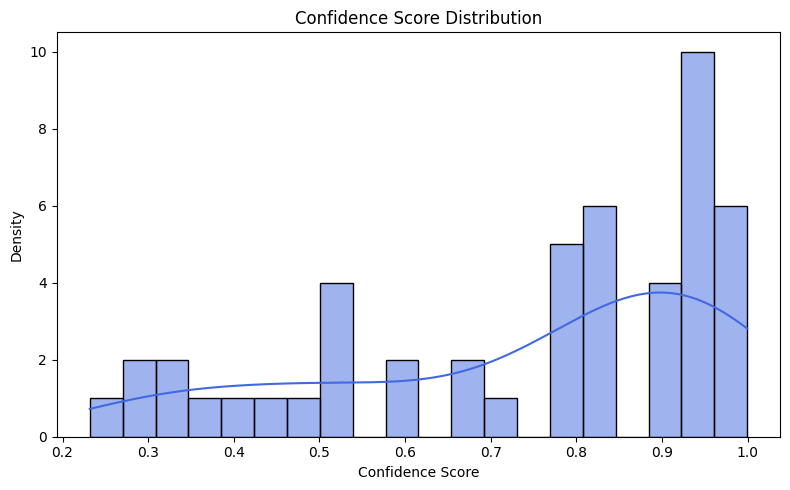

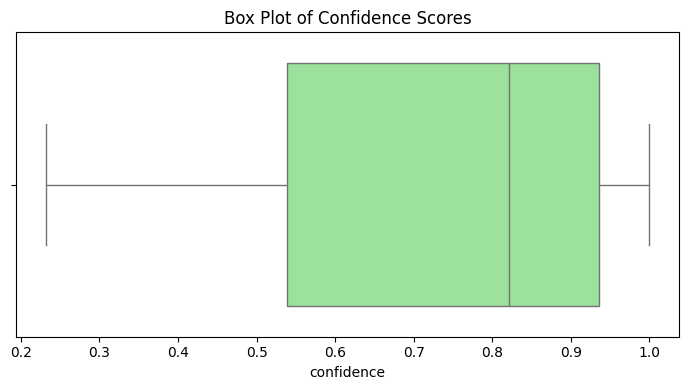

Shapiro-Wilk: statistic=0.869, p-value=0.000
Distribution of confidence scores is NOT normal.
95% CI for mean confidence: [0.678, 0.807]
T-test vs threshold 0.8: t-stat=-1.742, p-value=0.088


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve
from scipy.stats import shapiro, ttest_1samp

# Load your predictions (and ground truth if available)
df = pd.read_csv("face_predictions.csv")
# If you have ground truth, merge with prediction file
gt = pd.read_csv("ground_truth.csv")  # If available
merged = pd.merge(df, gt, on=["image_file","x","y","w","h"])

# ---- Descriptive Stats on Confidence ----
print(df['confidence'].describe())

# ---- Confidence Score Distribution ----
plt.figure(figsize=(8,5))
sns.histplot(df['confidence'], bins=20, kde=True, color='royalblue')
plt.title("Confidence Score Distribution")
plt.xlabel("Confidence Score")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

# ---- Boxplot ----
plt.figure(figsize=(7,4))
sns.boxplot(x='confidence', data=df, color='lightgreen')
plt.title("Box Plot of Confidence Scores")
plt.tight_layout()
plt.show()

# ---- Normality Test ----
sw_stat, sw_p = shapiro(df['confidence'])
print(f"Shapiro-Wilk: statistic={sw_stat:.3f}, p-value={sw_p:.3f}")
if sw_p < 0.05:
    print("Distribution of confidence scores is NOT normal.")
else:
    print("Distribution looks normal.")

# ---- Confidence Interval for Mean Confidence ----
mean = df['confidence'].mean()
std = df['confidence'].std()
n = len(df)
se = std / np.sqrt(n)
ci_l = mean - 1.96 * se
ci_r = mean + 1.96 * se
print(f"95% CI for mean confidence: [{ci_l:.3f}, {ci_r:.3f}]")

# ---- T-test vs Threshold ----
t_stat, t_p = ttest_1samp(df['confidence'], 0.8)
print(f"T-test vs threshold 0.8: t-stat={t_stat:.3f}, p-value={t_p:.3f}")

# ---- If ground truth available: Confusion Matrix, Precision, Recall, ROC ----
if "true_UID" in merged.columns:
   y_true, y_pred = merged['true_UID'], merged['predicted_UID']
   print(classification_report(y_true, y_pred))
   cm = confusion_matrix(y_true, y_pred)
   plt.figure(figsize=(8,6))
   sns.heatmap(cm, annot=True, fmt="d")
   plt.title("Confusion Matrix")
   plt.show()
#    # ROC/PR curve plotting here as needed


count    49.000000
mean      0.742509
std       0.231016
min       0.231831
25%       0.538172
50%       0.820824
75%       0.935798
max       0.999393
Name: confidence, dtype: float64

Predictions per student:
                 count      mean       std       min       25%       50%  \
predicted_UID                                                              
23BCA10299         3.0  0.808644  0.234242  0.538172  0.740137  0.942102   
23BCA10356         2.0  0.645830  0.184475  0.515387  0.580608  0.645830   
23BCA10806         2.0  0.641504  0.061779  0.597820  0.619662  0.641504   
23MCA20133         1.0  0.927427       NaN  0.927427  0.927427  0.927427   
23MCA20156         2.0  0.814492  0.039041  0.786886  0.800689  0.814492   
23MCA20215         2.0  0.998971  0.000597  0.998549  0.998760  0.998971   
23MCA20267         1.0  0.339888       NaN  0.339888  0.339888  0.339888   
23MCA20302         1.0  0.231831       NaN  0.231831  0.231831  0.231831   
23MCA20370         1.0  0.425

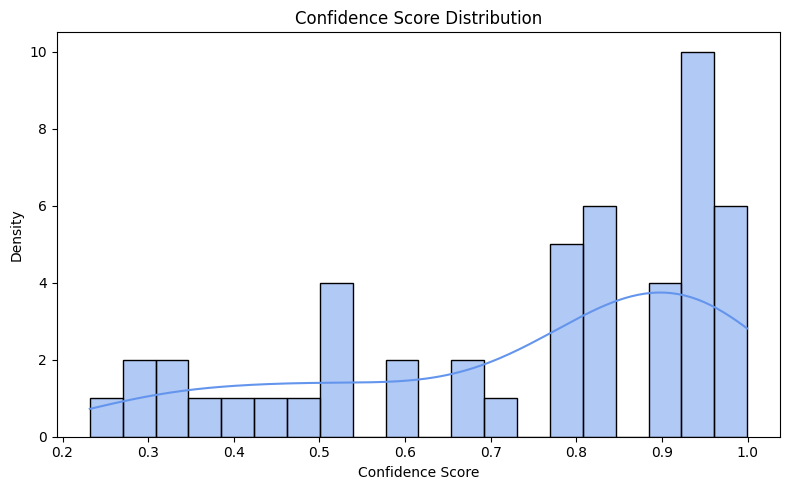

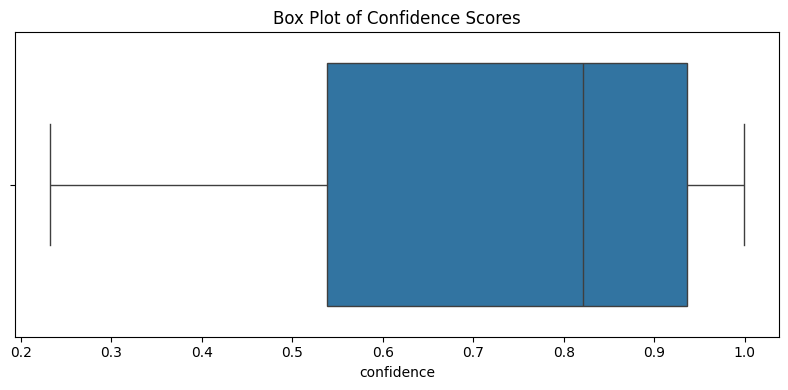

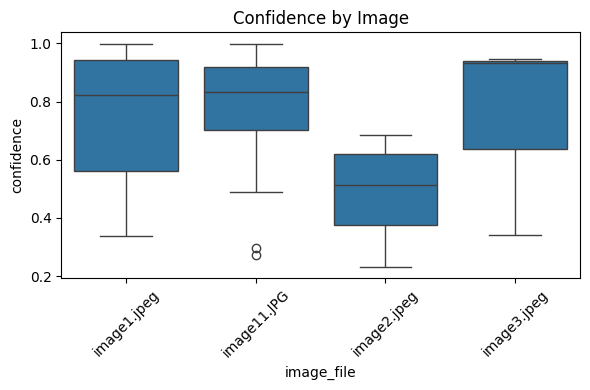

Shapiro-Wilk: statistic=0.869, p-value=0.000
Confidence distribution is NOT normal.
95% CI for mean confidence: [0.678, 0.807]
T-test vs 0.8: t-stat=-1.742, p-value=0.088
Mean confidence is not significantly different from 0.8.


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, ttest_1samp

df = pd.read_csv('face_predictions.csv')

# 1. Descriptive statistics
print(df['confidence'].describe())
print("\nPredictions per student:")
print(df.groupby('predicted_UID')['confidence'].describe())

# 2. Confidence Score Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['confidence'], bins=20, kde=True, color='cornflowerblue')
plt.title("Confidence Score Distribution")
plt.xlabel("Confidence Score")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

# 3. Boxplot
plt.figure(figsize=(8,4))
sns.boxplot(x='confidence', data=df)
plt.title("Box Plot of Confidence Scores")
plt.tight_layout()
plt.show()

# 4. Per-image average confidence
plt.figure(figsize=(6,4))
sns.boxplot(x='image_file', y='confidence', data=df)
plt.title("Confidence by Image")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 5. Normality test
sw_stat, sw_p = shapiro(df['confidence'])
print(f"Shapiro-Wilk: statistic={sw_stat:.3f}, p-value={sw_p:.3f}")
if sw_p < 0.05:
    print("Confidence distribution is NOT normal.")
else:
    print("Confidence distribution looks normal.")

# 6. Confidence interval for mean
mean = df['confidence'].mean()
std = df['confidence'].std()
n = len(df)
se = std / np.sqrt(n)
ci_l = mean - 1.96 * se
ci_r = mean + 1.96 * se
print(f"95% CI for mean confidence: [{ci_l:.3f}, {ci_r:.3f}]")

# 7. T-test vs threshold (e.g., 0.8)
t_stat, t_p = ttest_1samp(df['confidence'], 0.8)
print(f"T-test vs 0.8: t-stat={t_stat:.3f}, p-value={t_p:.3f}")
if t_p < 0.05:
    print("Mean confidence is significantly different from 0.8.")
else:
    print("Mean confidence is not significantly different from 0.8.")
